### Startup example for modeling chamber networks

In [1]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt

import cnetwork

In [2]:
# Fix random seed for reproducible distribution
np.random.seed(0)

In [3]:
# Set default properties--these are what each magma chamber takes as default if
# properties are not individually specified for each chamber.

crust_props = cnetwork.default_props(
  t_b_default=1e14,           # Maxwell / relaxation time (in isotropic strain) (Pa)
  t_d_default = 5e10,         # Maxwell / relaxation time (in deviatoric strain) (Pa)
  K_crust_default = 10e9,     # Bulk modulus of crust (Pa)
  G_crust_default = 10e9,     # Shear modulus of crust (Pa)
  K_f_default = 10e9,         # Bulk modulus of fluid / melt (Pa)
  r_hydr_default = 5,        # Hydraulic radius of channels / dikes (m)
  mu_default = 1e6,           # Melt viscosity in crust, constant (Pa s)
)

other_props = dict(
  R_min = 500,                # Minimum radius of magma chamber for random generation (m)
  R_max = 500,                # Maximum radius of magma chamber for random generation (m)
  N_chamber = 25,             # Number of chambers to generate
  x_scale = 40e3,             # Length scale of horizontal (x) direction (m)
  z_scale = 40e3,             # Length scale of horizontal (x) direction (m)
  mass_in_rate = 3.0,         # Input mass rate at bottom node (kg / s)
  p_erupt = 5e6,              # Overpressure required for eruption at top node (Pa)
  dpdx_crit = 1e2,            # Minimum pressure gradient for opening dike (Pa / m)
  dpdx_threshold_scale = 0.0, # Numerical smoothing parameter for dpdx_crit (Pa / m)
  # Eruption parameters (the erupting conduit is treated differently from dikes between chambers)
  mu_erupt = 1e5,             # Melt viscosity in erupting conduit (Pa s)
  r_conduit_erupt = 25,       # Conduit radius for erupting conduit (m)
  rhoref = 2500,              # Reference density of fluid / melt (Pa)
)

numerics = cnetwork.default_numerics()

Using these chosen properties, we set up the magma chamber system below. This prepares the system of differential equations of the form
$$
\frac{d \mathbf{q}}{dt} = f(t, \mathbf{q})
$$
$$
\mathbf{q}(t = 0) = \mathbf{q}_0
$$
to be solved, but does not yet solve the equations.

In [4]:
# Unpack the props dictionary
t_b = crust_props["t_b_default"]
t_d = crust_props["t_d_default"]
K_crust = crust_props["K_crust_default"]
G_crust = crust_props["G_crust_default"]
K_f = crust_props["K_f_default"]
r_hydr = crust_props["r_hydr_default"]
mu0 = crust_props["mu_default"]

R_min = other_props["R_min"]
R_max = other_props["R_max"]
N_chamber = other_props["N_chamber"]
x_scale = other_props["x_scale"]
z_scale = other_props["z_scale"]
rhoref = other_props["rhoref"]

# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3
# List generation of chamber characteristics
x_nodes = x_scale * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
# Fix bottom and top nodes
z_nodes[0] = 0.0
z_nodes[-1] = z_scale
x_nodes[0] = 0.5 * x_scale
x_nodes[-1] = 0.5 * x_scale
# Generate random magma chamber size (if R_max == R_min, no randomness)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Generate list of MagmaChamber nodes, which store the volume, mass, energy in chamber
list_nodes = [cnetwork.MagmaChamber(x=x, y=y, z=z,
  p_setting=None, vref=1.0/rhoref,
  T_setting=1000+273.15, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

# Set up main system for timestepping later
global_sys = cnetwork.GlobalSystemThreshold(list_nodes, **crust_props,
  **numerics, dpdx_crit=other_props["dpdx_crit"],
  dpdx_threshold_scale=other_props["dpdx_threshold_scale"],
  max_edge_dist=np.inf)

# Add source term due to mass injection at node 0
# This is a function that is passed to global_sys.simulation
f_inj = global_sys.create_single_mass_injection_source(other_props["mass_in_rate"])
# Add source term due to eruption at node -1
# This is a function that is passed to global_sys.simulation
f_erupt = global_sys.create_eruption_source(p_erupt=other_props["p_erupt"],
                                            mu_erupt=other_props["mu_erupt"],
                                            r_conduit=other_props["r_conduit_erupt"])

Below we compute the numerical solution to the system of differential equations for a given time vector.

In [5]:
# Time-dependent  simulation
t_vec = np.linspace(0, 1e11, 1600)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

In [6]:
print("q_out has shape:")
print(f"  {q_out.shape}")
print("equal to (size of t_vec, number of state variables)).")
print("")
print("For example, q_out[i,:] is the state vector q at time t_vec[i].")
print("Next, let's parse this output data.")

q_out has shape:
  (1600, 2600)
equal to (size of t_vec, number of state variables)).

For example, q_out[i,:] is the state vector q at time t_vec[i].
Next, let's parse this output data.


In [7]:
# Extract useful variables from q
m_hist, p, u = global_sys.compute_m_p_u(q_out)
m_hist.shape, p.shape, u.shape, m_erupted_out.shape

((1600, 25), (1600, 25), (1600, 25), (1600,))

Some useful quantities that `post_process` computes:
* `m_hist`: Mass history of each chamber (kg) -- shape (size of `t_vec`, `N_chamber`)
* `p`: Pressure in each chamber (Pa) -- shape (size of `t_vec`, `N_chamber`)
* `u`: Wall displacement (radially symmetric) for each chamber (m) -- shape (size of `t_vec`, `N_chamber`)
* `m_erupted_out`: History of erupted mass (kg) -- shape (size of `t_vec`)


For looking at the viscoelastic relaxation of the crust around a given chamber, we can parse the viscous strain from `q_out`.

For a viscoelastic material, the total strain is given by
$$
\varepsilon_{ij} = \varepsilon_{ij}^\mathrm{el} + \gamma_{ij},
$$
where $\varepsilon_{ij}$ is the total strain (tensor), $\varepsilon_{ij}^\mathrm{el}$ is the elastic strain, and $\gamma_{ij}$ is the viscous strain. The elastic strain is proportional to the stress
$$
\varepsilon_{ij}^\mathrm{el} = A_{ijkl} \sigma_{kl},
$$
where $A_{ijkl}$ is an elastic tensor. On the other hand, $\gamma_{ij}$ is a time-dependent quantity. When $\varepsilon_{ij} = \gamma_{ij}$, all stress in the material is "relaxed", and $\sigma_{ij} = 0$.

In [8]:
# Pick a chamber index -- any index in [0, N_chambers)
chamber_index = 0
# Extract the rr-deviatoric viscous strain
gamma_drr = q_out[:, global_sys.data_slice_global(chamber_index, "gamma_drr")]
# Extract the trace of viscous strain
gamma_kk = q_out[:, global_sys.data_slice_global(chamber_index, "gamma_kk")]
# Compute the rr viscous strain
gamma_rr = gamma_drr + gamma_kk/3.0

print(f"gamma_rr has shape {gamma_rr.shape} == (size of t_vec, number of radial gridpoints)")

gamma_rr has shape (1600, 50) == (size of t_vec, number of radial gridpoints)


Text(0, 0.5, 'Erupted mass (kg)')

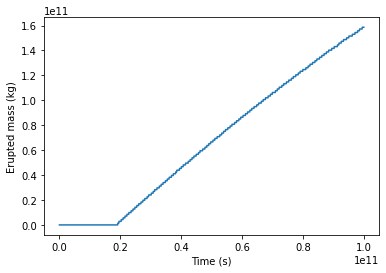

In [9]:
plt.plot(t_vec, m_erupted_out)
plt.xlabel("Time (s)")
plt.ylabel("Erupted mass (kg)")

Text(0, 0.5, 'Pressure (MPa) of top chamber')

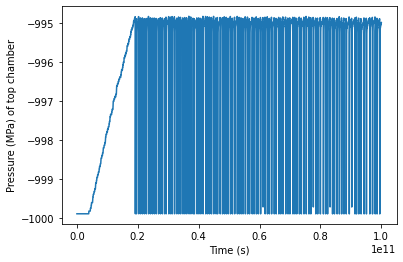

In [10]:
plt.plot(t_vec, p[:,-1] / 1e6)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (MPa) of top chamber")

#### Plot tools
At this point, no graph theory tools are needed. We've only solved the system of differential equations and looked at some of the outputs.

Let's look at some more useful quantities. In make_composite_plot, we show 4 panels:
  1. Mass erupted divided by mass added to the magma chamber network at the bottom
  2. Change in mass since beginning of the simulation (color corresponds to different chambers; black is erupted)
  3. Cumulative erupted mass
  4. Mass passing through a given depth at a given time. Color intensity corresponds to mass rate (mass per time). Conceptually, this corresponds to picking a time $t$ and depth $z$, and then taking a horizontal slice across the crust at depth $z$; for each dike that this slice cuts across, we add the mass flowing through that dike to the total color at ($t$, $z$).


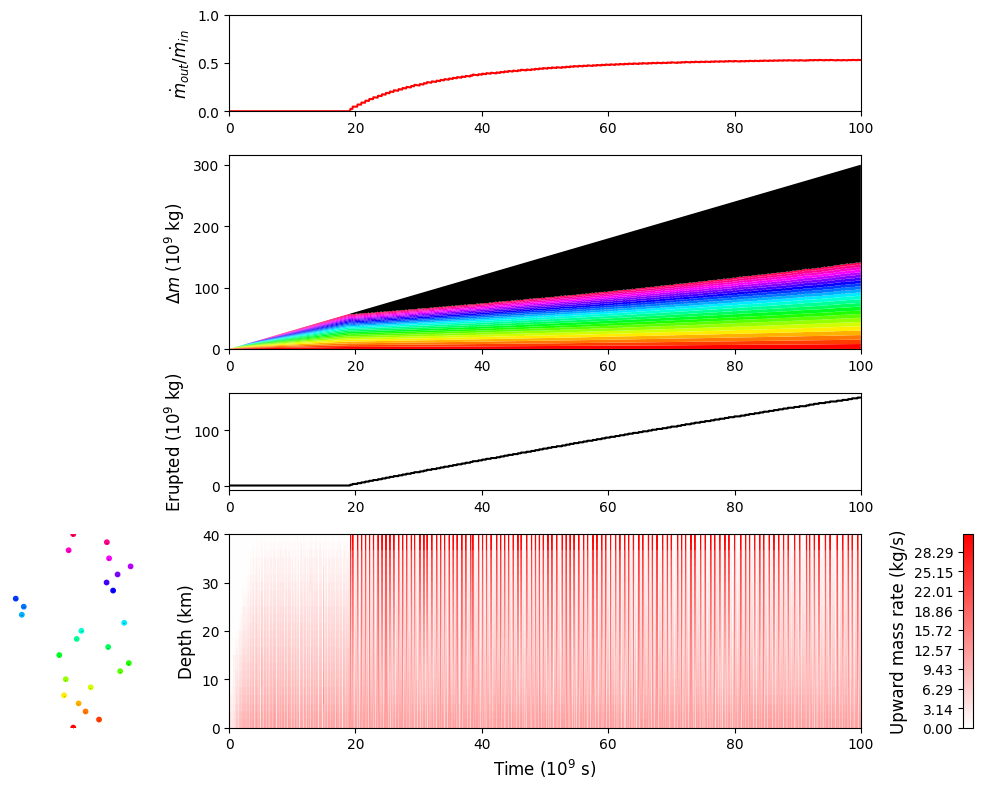

In [11]:
fig, axes = global_sys.make_composite_plot(t_vec, q_out, m_erupted_out, z_samples=200)


#### Graph tools
Graph theory tools can be used to gain further insight into the simulation.

We can think about the chamber network as a graph with magma chambers as nodes or vertices ($V$), and dikes between them as edges ($E$) in the graph. As such, the magma network is a graph $G = (V, E)$ at a given time $t$.

For a fixed time $t$, we can compute the net hydraulic conductivity of the network, as a measure of how permeable the crust is (from the perspective of a network of chambers). The hydraulic conductivity of an edge is defined here as the mass rate flow per pressure difference; that is, between nodes $i$ and $j$,
$$
Y_{ij} = \frac{\text{volume flux per second between chambers i and j}}{|p_i - p_j|}.
$$
Volume flux has units of (m/s). If $Y_{ij} = 0$, the chambers $i$ and $j$ are not connected. Otherwise, the higher $Y_{ij}$ is, the easier it is for fluid to flow between the nodes $i$ and $j$. Here we use the absolute value of volume flux (whether flow goes from $i$ to $j$ or $j$ to $i$ doesn't matter, and $Y_{ij} \geq 0$).

We call $Y$ the matrix with entries $Y{ij}$.

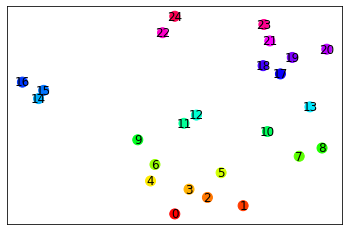

In [12]:
import networkx as nx

# Pick a time index
time_index = -6 # 6th last time index
# Compute the hydraulic connectivity matrix (weighted adjacency matrix)
Y = global_sys.get_connectivity(q_out[time_index,:])

# Buidl a directed graph
G = nx.DiGraph(Y)

# Prepare for graph plotting
length_scale = 1e3
# Define Node index-position mapping (2D projection)
pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(global_sys.nodes)}
# Extract volume of node
V_nodes = np.array([node.V for node in global_sys.nodes])

# Plot settings
node_scale = 100
node_size = node_scale*V_nodes/V_nodes.max()
cmap = matplotlib.cm.hsv
colors =  cmap(np.linspace(0,1,global_sys.num_blocks,endpoint=False))
nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
                        edge_cmap=(0, 1), ax=plt.gca())

Instead of a fixed time $t$, we can plot the time-averaged conductivity of the network, as a measure of how permeable the crust is (from the perspective of a network of chambers) over a *long timescale*.


In [13]:
def get_time_averaged_connectivity(_t, _m, _p, _u, _q, _m_out, _global_sys, averaged=True):
  Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

  Y = np.zeros((_t.size, num_blocks, num_blocks))

  def smoother(x, scale):
    ''' Returns one-sided compact smoothed step, such that
      1. u(x < -scale) = 0
      2. u(x >= 0) = 1.
      3. u smoothly interpolates from 0 to 1 in between.
    '''
    # Shift, scale, and clip to [-1, 0] to prevent exp overflow
    if scale != 0:
      _x = np.clip(x / scale + 1, 0, 1)
    else:
      _x = np.where(x >= 0, 1, 0)
    f0 = np.exp(-1/np.where(_x == 0, 1, _x))
    f1 = np.exp(-1/np.where(_x == 1, 1, 1-_x))
    # Return piecewise evaluation
    return np.where(_x >= 1, 1,
          np.where(_x <= 0, 0, 
          f0 / (f0 + f1)))

  for i in range(num_blocks):
    node_i = _global_sys.nodes[i]
    for j in range(num_blocks):
      if i == j:
        continue
      node_j = _global_sys.nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > _global_sys.max_edge_dist:
        continue
      # Compute average pressure gradient
      dpdx = (_p[:,i] - _p[:,j]) / dist
      # Resolve remote tensile stress in x-direction
      opening_stress = _global_sys.remote_sigma_xx * np.abs(node_i.z - node_j.z)/ dist
      # Effective pressure gradient
      dpdx_eff = dpdx
      # Effective critical pressure gradient for opening
      dpdx_crit_eff = _global_sys.dpdx_crit - opening_stress

      # Factor between (0, 1) that modulates flow between the two chambers
      if dpdx_crit_eff != 0:
        threshold_factor = smoother(np.abs(dpdx_eff) - dpdx_crit_eff,
                                    _global_sys.dpdx_threshold_scale) * (dpdx_eff > 0).astype(float)
        if np.any(threshold_factor > 1) or np.any(threshold_factor < 0):
          raise ValueError
      else:
        threshold_factor = np.ones_like(dpdx_eff)

      # Compute flow admittance ( (m/s) / Pa )
      Y[:,i,j] = threshold_factor * (
        _global_sys.r_hydr_default * _global_sys.r_hydr_default
        / 16.0 / _global_sys.mu_default / dist)

  if averaged:
    return Y.mean(axis=0)
  else:
    return Y

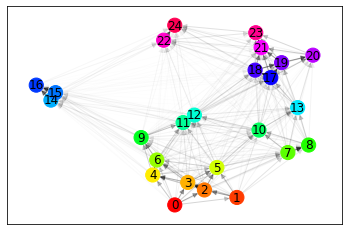

In [14]:

# Plot options
node_scale=200
plot_threshold=0.0
with_labels = True
arrows=True

# Calculate connectivity matrix at each time, then take average
Y_avg = get_time_averaged_connectivity(
  t_vec, m_hist, p, u, q_out, m_erupted_out, global_sys, averaged=True)

# Only plot for edge weights larger than plot_threshold
Y_avg = np.where(Y_avg / Y_avg.max() > plot_threshold, Y_avg, 0.0)

# Construct directed graph
G = nx.DiGraph(Y_avg)
# Node index-position mapping (2D projection)
length_scale = 1e3
pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(global_sys.nodes)}
V_nodes = np.array([node.V for node in global_sys.nodes])
# Set node appearance
node_size = node_scale*V_nodes/V_nodes.max()
node_colors =  matplotlib.cm.hsv(
  np.linspace(0,1,global_sys.num_blocks,endpoint=False))
# Take averaged conductivity Y as edge intensity
edge_intensity = (np.array(scipy.sparse.csr_matrix(Y_avg).data))
edge_intensity /= edge_intensity.max()

# Create new colormap
from matplotlib.colors import ListedColormap
custom_cmap_array = np.zeros((256,4))
custom_cmap_array[:,3] = np.linspace(0, 1 ,256)
custom_cmap = ListedColormap(custom_cmap_array)

nx.draw_networkx(G, pos,
                node_size=node_size,
                node_color=node_colors,
                edge_cmap=custom_cmap,
                # edge_cmap=matplotlib.cm.Greys,
                edge_color=edge_intensity, with_labels=with_labels, arrows=arrows)


In the above, arrows appear for hydraulic connections between chambers at some point in time during the simulation. Bolder arrows represent higher conductivity for flow (typically inversely proportional to the distance).

Some graph tools can provide useful scalar quantities describing the graph at a point in time (without having to examine the entire graph). One such quantity is the graph conductivity, computed from the graph Laplacian $\mathcal{L} = D - Y $, where $Y$ is the matrix of conductivities and $D$ is the degree matrix. The degree matrix is a diagonal matrix where each entry on the diagonal is the row-sum of $Y$.

The intuitive explanation for the effective conductivity/connectivity of a graph between nodes $i$ and $j$ is to think about reducing the graph to only nodes $i$ and $j$, connected by a single edge with hydraulic connectivity $Y_\mathrm{effective}$. The value of $Y_\mathrm{effective}$ is the effective conductivity, and since our graph is time-dependent, $Y_\mathrm{effective}$ is a time-dependent quality.

Here we will only consider the effective conductivity between the bottom-most node (where the melt is added) and the top-most node (where the melt is erupted), effectively replacing the rest of the network between these two nodes.

In [15]:
connectivity_output = global_sys.compute_effective_connectivity(t_vec, q_out, window_nodes_vec=[1])
# Unpack the output: n is the time-averaging window size used (in this case just 1)
# dt_window: the timestep over which averaging happens (in this case just the simulation timestep dt)
# t_avg_range: window-averaged time vector (in this case just t_vec)
# effective_cond: effective hydraulic conductivity at each time t 
n, dt_window, t_avg_range, effective_cond = connectivity_output[0]

Text(0, 0.5, 'Effective conductivity ((m/s) / Pa)')

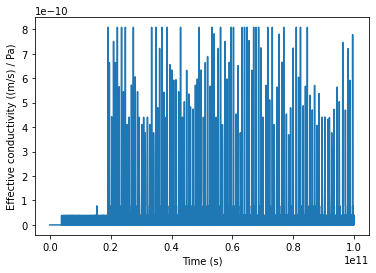

In [16]:
plt.plot(t_vec, effective_cond)
plt.xlabel("Time (s)")
plt.ylabel("Effective conductivity ((m/s) / Pa)")